#  Supposedly great title

Description


In [1]:
print("I'm working")

I'm working


In [4]:
%pip install uproot awkward matplotlib numpy

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import uproot
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import awkward as ak
import re
import math
import ROOT 
import os, sys, importlib

os.chdir('/scratch1/gjedrzej/Lab') #GJ path
sys.path.append(os.path.join(os.getcwd(), "python"))

output_dir = 'analysis/processedData'

if not os.path.exists(output_dir):
    os.makedirs(output_dir, exist_ok=True)
    print(f"Created directory: {output_dir}")

/scratch1/gjedrzej/.local/lib/python3.9/site-packages/ROOT/__init__.py:5: UserWarning: 
This distribution of ROOT is in alpha stage. Feedback is welcome and appreciated. Feel free to reach out to the user forum for questions and general feedback at https://root-forum.cern.ch or to submit an issue at https://github.com/root-project/root/issues. Do not rely on this distribution for production purposes.

  warnings.warn(
/scratch1/gjedrzej/.local/lib/python3.9/site-packages/cppyy/__init__.py:374: UserWarning: CPyCppyy API not found (tried: /usr/include/site/python3.9); set CPPYY_API_PATH envar to the 'CPyCppyy' API directory to fix
  warnings.warn("CPyCppyy API not found (tried: %s); "


In [3]:
#Kod J. Skwarek
#Lista kodów PDG cząstek neutralnych, które chcemy usunąć ze zbioru danych
neutral_particles = [
    -12, 12, -14, 14, -16, 16,
    -3122, 3122, -3212, 3212, -421, 421, -311, 311,
    -130, 130, 2000000101, 1000180400, 130, 310,
    3322, -3322, 221, 331, 443, 2112, -2112
]

In [4]:
#Kod J. Skwarek 
def parse_interaction_code(code_str):
    current = "CC" if "CC" in code_str else "NC" if "NC" in code_str else "UNK"
    if "DIS" in code_str: interaction = "DIS"
    elif "RES" in code_str: interaction = "RES"
    elif "QES" in code_str: interaction = "QES"
    else: interaction = "OTHER"
    return current, interaction

In [5]:
#Kod J. Skwarek - zmodyfikowany 
def extract_data_hybrid(input_path, output_csv, neutral_particles):
    # --- 1. Get EvtCode using PyROOT (Safe for Strings) ---
    print("Extracting metadata with PyROOT...")
    rf = ROOT.TFile.Open(input_path)
    r_tree = rf.Get("gRooTracker")
    
    evt_codes = []
    for entry in r_tree:
        # PyROOT handles the TObjString/TObject conversion automatically
        evt_codes.append(entry.EvtCode.GetString().Data())
    rf.Close()

    # --- 2. Get Physics Data using Uproot (Fast & Stable) ---
    print("Extracting physics data with Uproot...")
    with uproot.open(input_path + ":gRooTracker") as tree:
        # Exclude EvtCode here to avoid the UnknownInterpretation error
        branches = ["EvtNum", "StdHepN", "StdHepPdg", "StdHepStatus", "StdHepP4"]
        data = tree.arrays(branches)

        pdg = data["StdHepPdg"]
        status = data["StdHepStatus"]
        p4 = data["StdHepP4"]

        # --- 3. Filtering Logic ---
        # Final state mask
        mask = (status == 1)
        for code in neutral_particles:
            mask = mask & (pdg != code)

        # Momentum cut for protons (PDG 2212)
        px, py, pz = p4[:, :, 0], p4[:, :, 1], p4[:, :, 2]
        momentum = np.sqrt(px**2 + py**2 + pz**2)
        mask = mask & ~((pdg == 2212) & (momentum < 0.4))

        final_pdgs = pdg[mask]
        final_p4s = p4[mask]

        # --- 4. Building Rows ---
        rows = []
        for i in range(len(data["EvtNum"])):
            current_type, interaction_type = parse_interaction_code(evt_codes[i])
            row = [data["EvtNum"][i], current_type, interaction_type]
            
            p_info = []
            for p_idx in range(min(len(final_pdgs[i]), 4)):
                p_info.append(final_pdgs[i][p_idx])
                p_info.extend(final_p4s[i][p_idx].tolist())
            
            while len(p_info) < 20: p_info.append(None)
            rows.append(row + p_info[:20])

        # --- 5. Save ---
        df = pd.DataFrame(rows)
        header = ["EvtNum", "CurrentType", "InteractionType"]
        for i in range(1, 5):
            header.extend([f"P{i}_id", f"P{i}_px", f"P{i}_py", f"P{i}_pz", f"P{i}_E"])
        
        df.to_csv(output_csv, header=header, index=False)
        print(f"Done! Saved to {output_csv}")

# All data 0.5-80 (Full NC)

In [ ]:
FilePath = "/scratch1/gjedrzej/Lab/data/nu_tau_05__80_interactions.gtrac.root"
output_path = os.path.join(output_dir, 'data_tau.csv')
extract_data_hybrid(FilePath, output_path, neutral_particles)

Extracting metadata with PyROOT...
Extracting physics data with Uproot...
Done! Saved to analysis/processedData/data_tau.csv


In [54]:
df = pd.read_csv(output_path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   EvtNum           100000 non-null  int64  
 1   CurrentType      100000 non-null  object 
 2   InteractionType  100000 non-null  object 
 3   P1_id            34588 non-null   float64
 4   P1_px            34588 non-null   float64
 5   P1_py            34588 non-null   float64
 6   P1_pz            34588 non-null   float64
 7   P1_E             34588 non-null   float64
 8   P2_id            4338 non-null    float64
 9   P2_px            4338 non-null    float64
 10  P2_py            4338 non-null    float64
 11  P2_pz            4338 non-null    float64
 12  P2_E             4338 non-null    float64
 13  P3_id            99 non-null      float64
 14  P3_px            99 non-null      float64
 15  P3_py            99 non-null      float64
 16  P3_pz            99 non-null      float

In [48]:
#clean nulls
print(f"Number of events before cleaning: {len(df)}")
df = df.dropna(subset=['EvtNum', 'CurrentType', 'InteractionType'])
df.info()
df.head()
print(f"Number of events after cleaning: {len(df)}")

Number of events before cleaning: 100000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   EvtNum           100000 non-null  int64  
 1   CurrentType      100000 non-null  object 
 2   InteractionType  100000 non-null  object 
 3   P1_id            34588 non-null   float64
 4   P1_px            34588 non-null   float64
 5   P1_py            34588 non-null   float64
 6   P1_pz            34588 non-null   float64
 7   P1_E             34588 non-null   float64
 8   P2_id            4338 non-null    float64
 9   P2_px            4338 non-null    float64
 10  P2_py            4338 non-null    float64
 11  P2_pz            4338 non-null    float64
 12  P2_E             4338 non-null    float64
 13  P3_id            99 non-null      float64
 14  P3_px            99 non-null      float64
 15  P3_py            99 non-null      float64
 16

In [6]:
#Visualize
def visualize_data(df):
    fig, axes = plt.subplots(2,2, figsize=(12, 12))

    axes[0,0].hist(df['CurrentType'], bins=3, alpha=0.7, color='blue')
    axes[0,0].set_title("Distribution of Current Types")
    axes[0,0].set_xlabel("Current Type")
    axes[0,0].set_ylabel("Number of Events")
    axes[0,0].grid(alpha=0.3)

    axes[0,1].hist(df['InteractionType'], bins=4, alpha=0.7, color='orange')
    axes[0,1].set_title("Distribution of Interaction Types")
    axes[0,1].set_xlabel("Interaction Type")
    axes[0,1].set_ylabel("Number of Events")
    axes[0,1].grid(alpha=0.3)

    pdg_map = {2212: "p", 2112: "n", 211: "pi+", -211: "pi-", 111: "pi0", 11: "e-", 13: "mu-", 15: "tau-", 22: "gamma", 321: "K+", -321: "K-", 3112: "Lambda", 3222: "Sigma+"}
    counts = df['P1_id'].dropna().value_counts().sort_index()
    labels = [pdg_map.get(int(i), str(int(i))) for i in counts.index]
    axes[1, 0].clear() # Clear the old histogram if re-running
    axes[1, 0].bar(range(len(counts)), counts.values, color='purple', alpha=0.7)
    axes[1, 0].set_xticks(range(len(counts)))
    axes[1, 0].set_xticklabels(labels, rotation=45, fontsize=9)
    axes[1, 0].set_title("Primary Particle (P1) Identity")
    axes[1, 0].set_ylabel("Events")
    axes[1, 0].grid(axis='y', alpha=0.3)
    plt.tight_layout()

    axes[1, 1].hist(df['P1_E'], bins=50, alpha=0.7, color='green')
    axes[1,1].set_title("Distribution of P1 Energy")
    axes[1,1].set_xlabel("P1 Energy")
    axes[1,1].set_ylabel("Number of Events")
    axes[1,1].grid(alpha=0.3)

    plt.show()

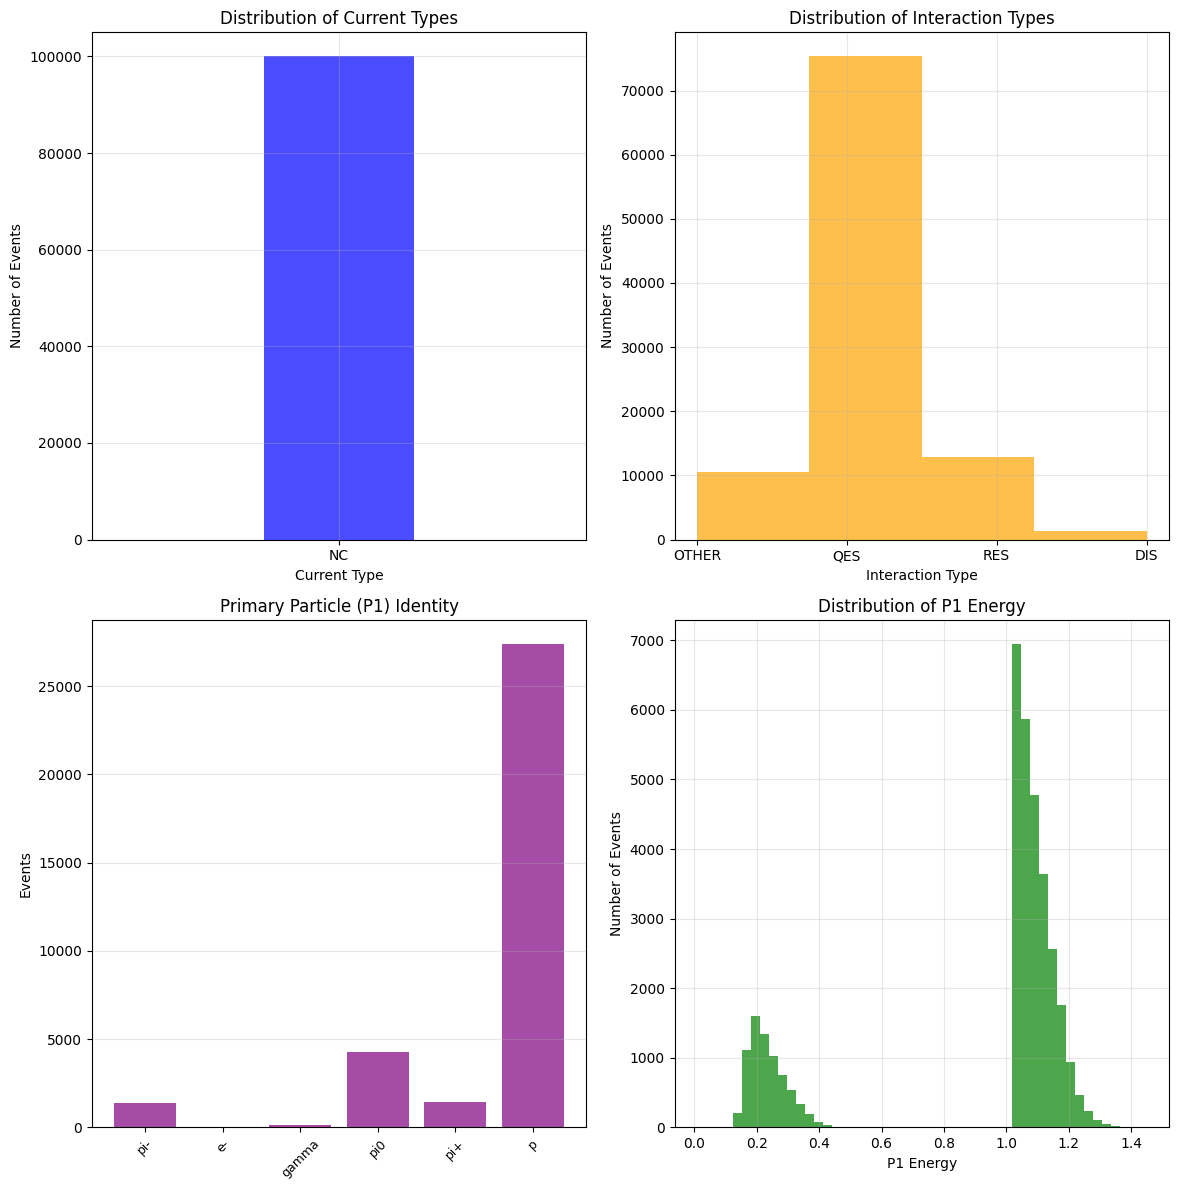

In [56]:
visualize_data(df)

# All Data 3.5-50

In [ ]:
file = '/scratch1/gjedrzej/Lab/data/nu_tau_3_5__50_interactions.gtrac.root'
output_path = os.path.join(output_dir, 'data_CC_NC.csv')
extract_data_hybrid(file, output_path, neutral_particles)


Extracting metadata with PyROOT...
Extracting physics data with Uproot...
Done! Saved to analysis/processedData/data_CC_NC.csv


NameError: name 'visualize_data' is not defined

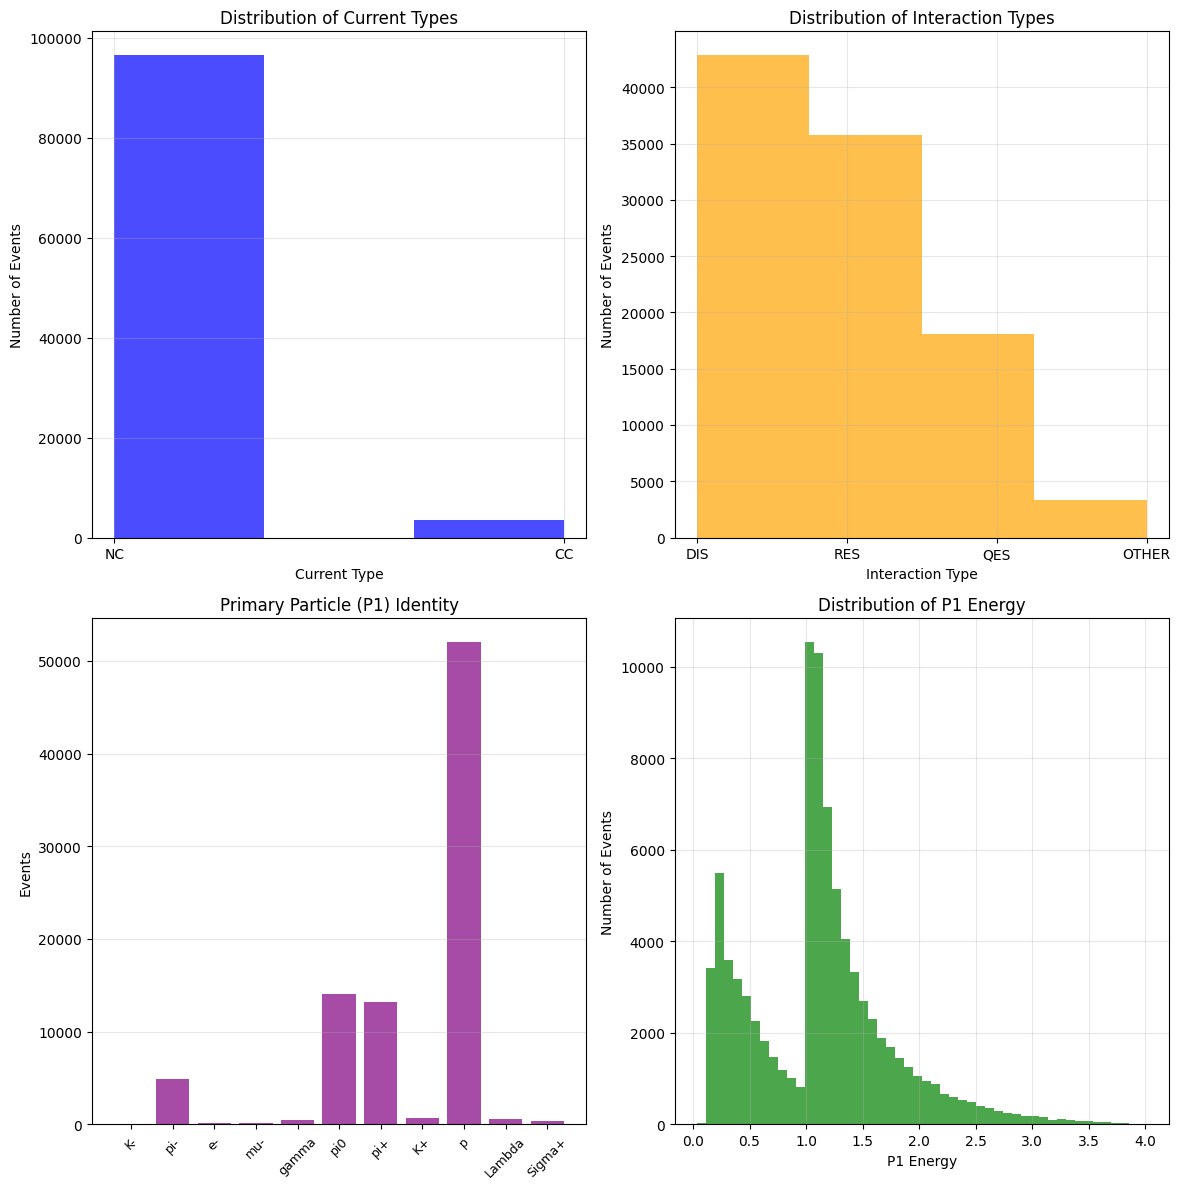

In [11]:
df_cc_nc = pd.read_csv(output_path)
df_cc_nc = df_cc_nc.dropna(subset=['EvtNum', 'CurrentType', 'InteractionType'])
visualize_data(df_cc_nc)

In [16]:
print("CC percentage:", (df_cc_nc['CurrentType'] == 'CC').mean() * 100)
print("Expected CC percentage: ~3.8%")
print("NC percentage:", (df_cc_nc['CurrentType'] == 'NC').mean() * 100)
print("Expected NC percentage: ~96.2%")

print("CC QES percentage:", ((df_cc_nc['CurrentType'] == 'CC') & (df_cc_nc['InteractionType'] == 'QES')).sum() / df_cc_nc['CurrentType'].eq('CC').sum() * 100)
print("Expected CC QES percentage: ~51%")

CC percentage: 3.504
Expected CC percentage: ~3.8%
NC percentage: 96.49600000000001
Expected NC percentage: ~96.2%
CC QES percentage: 79.16666666666666
Expected CC QES percentage: ~51%


# CC    3-80 GeV

In [13]:
%%time
file = '/scratch1/gjedrzej/Lab/data/nu_tau_CC_interactions.gtrac.root'
output_path = os.path.join(output_dir, 'data_CC.csv')
extract_data_hybrid(file, output_path, neutral_particles)

Extracting metadata with PyROOT...
Extracting physics data with Uproot...
Done! Saved to analysis/processedData/data_CC.csv
CPU times: user 4min 43s, sys: 1.48 s, total: 4min 45s
Wall time: 4min 44s


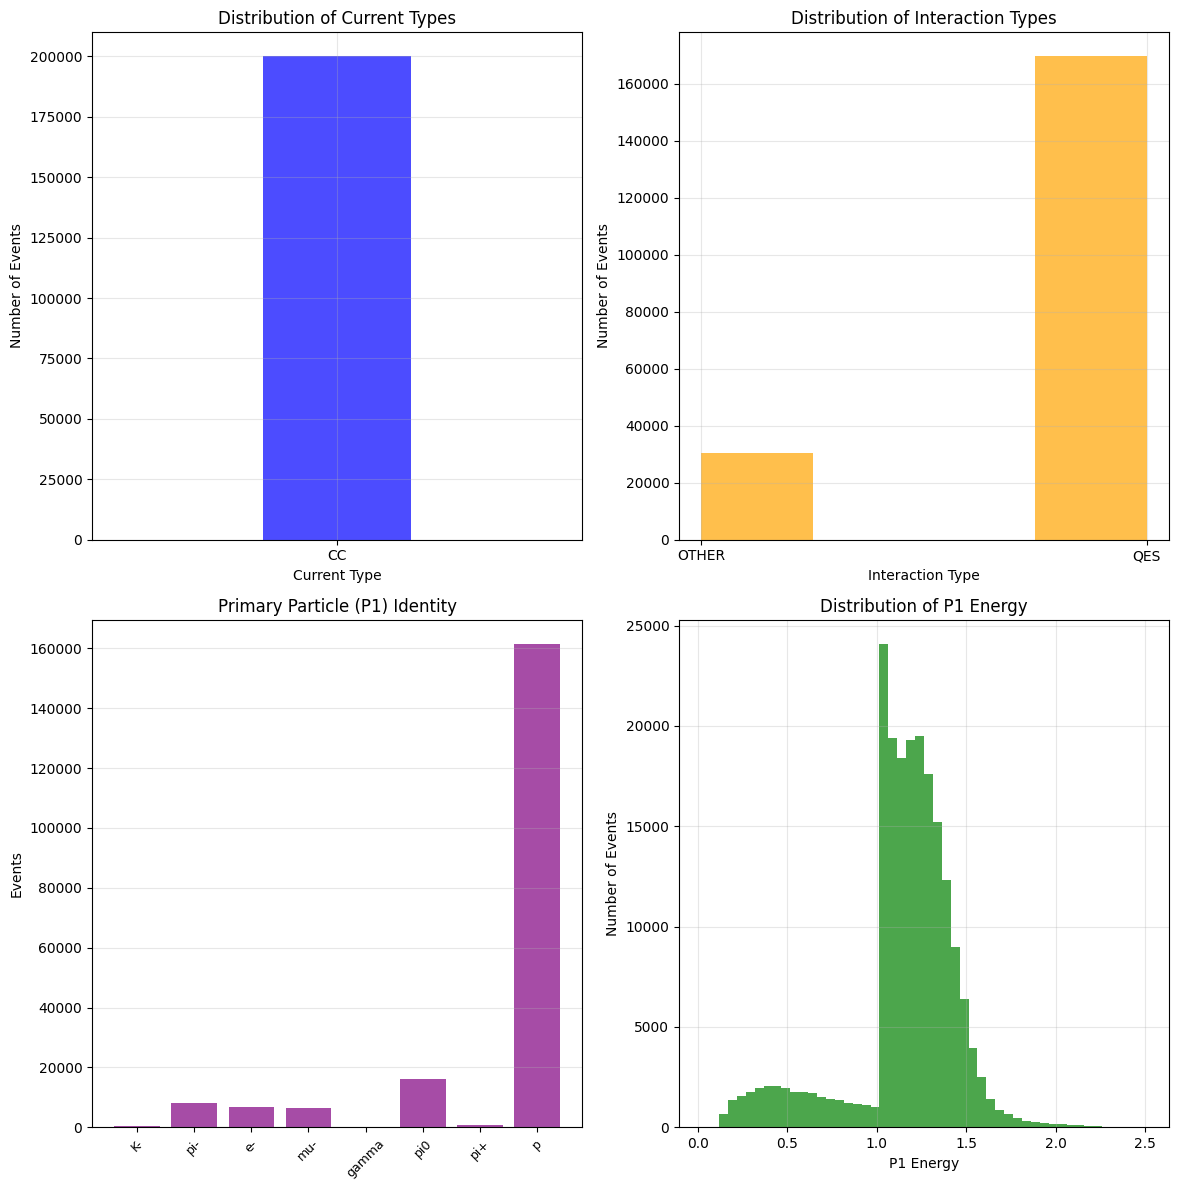

In [14]:
df_cc = pd.read_csv(output_path)
df_cc = df_cc.dropna(subset=['EvtNum', 'CurrentType', 'InteractionType'])
visualize_data(df_cc)

In [16]:
print("CC QES percentage:", ((df_cc['CurrentType'] == 'CC') & (df_cc['InteractionType'] == 'QES')).sum() / df_cc['CurrentType'].eq('CC').sum() * 100)
print("Expected CC QES percentage: ~51%")

CC QES percentage: 84.803
Expected CC QES percentage: ~51%


# NC 1-10 GeV

In [7]:
file = '/scratch1/gjedrzej/Lab/data/nu_tau_NC_interactions.gtrac.root'
output_path = os.path.join(output_dir, 'data_NC.csv')
extract_data_hybrid(file, output_path, neutral_particles)


Extracting metadata with PyROOT...
Extracting physics data with Uproot...
Done! Saved to analysis/processedData/data_NC.csv


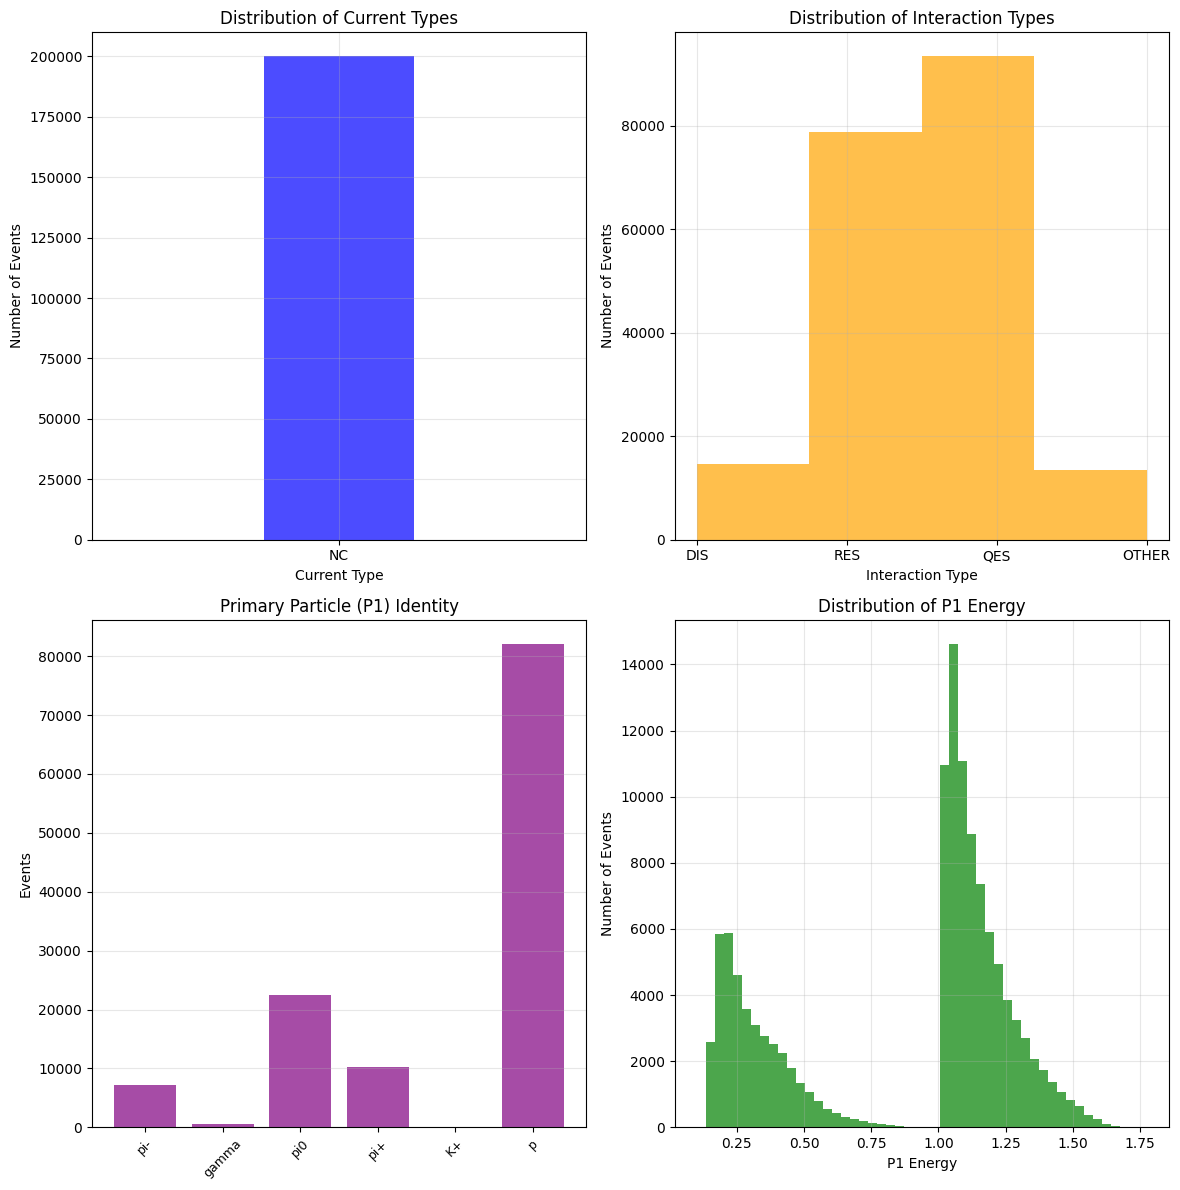

In [8]:
df_nc = pd.read_csv(output_path)
df_nc = df_nc.dropna(subset=['EvtNum', 'CurrentType', 'InteractionType'])
visualize_data(df_nc)

# NC_2 3-10 GeV

In [9]:
file = '/scratch1/gjedrzej/Lab/data/nu_tau_NC2_interactions.gtrac.root'
output_path = os.path.join(output_dir, 'data_NC2.csv')
extract_data_hybrid(file, output_path, neutral_particles)


Extracting metadata with PyROOT...
Extracting physics data with Uproot...
Done! Saved to analysis/processedData/data_NC2.csv


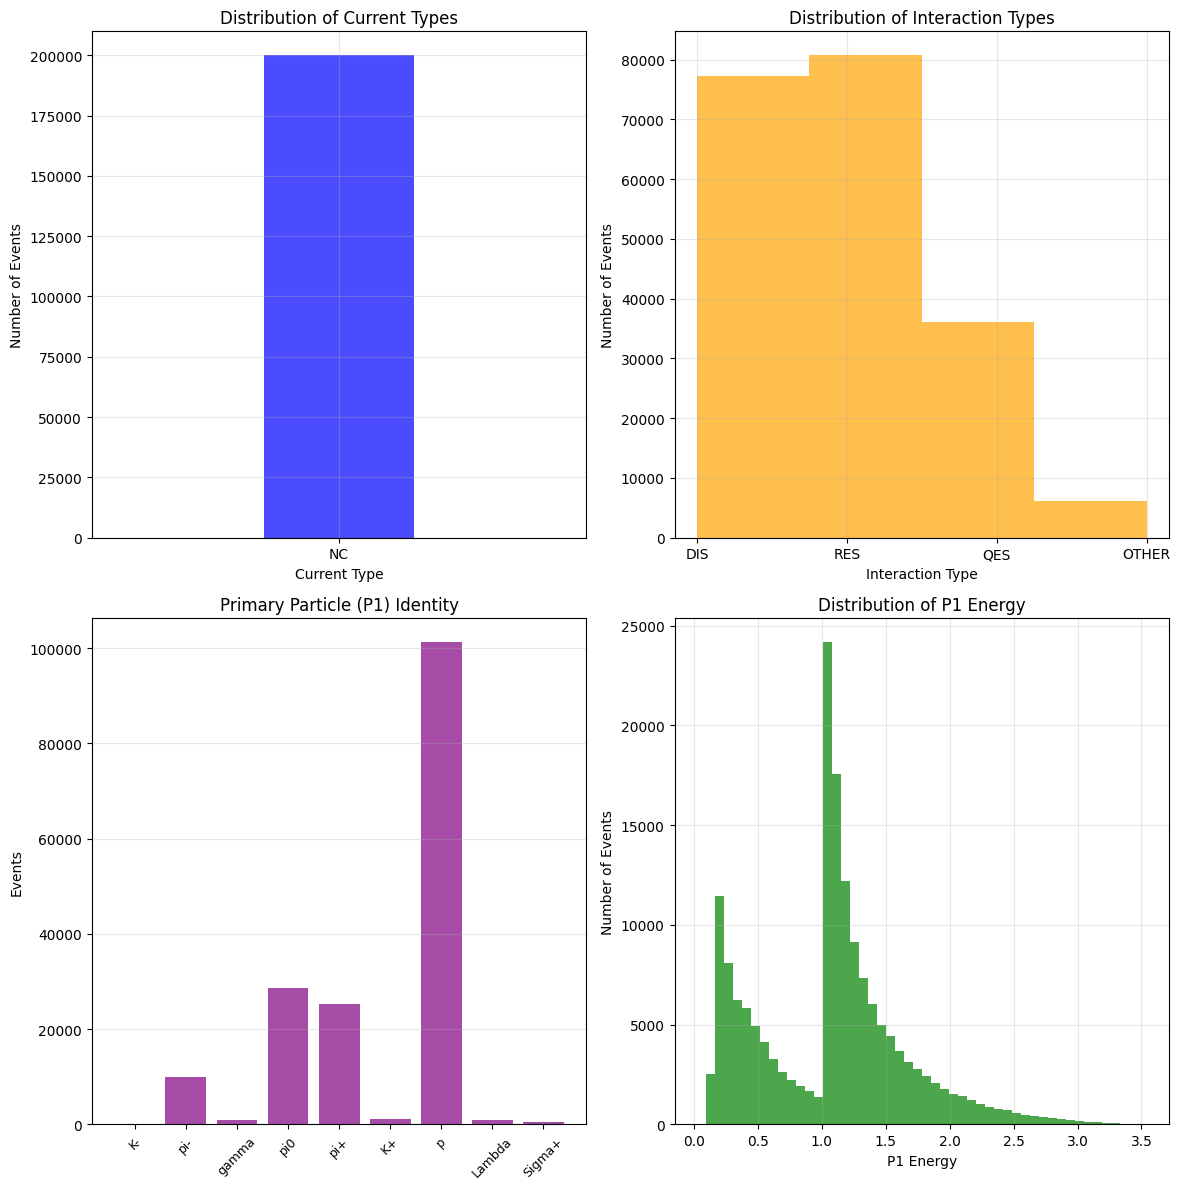

In [10]:
df_nc2 = pd.read_csv(output_path)
df_nc2 = df_nc2.dropna(subset=['EvtNum', 'CurrentType', 'InteractionType'])
visualize_data(df_nc2)

# CC Energy (needs clarification)

In [ ]:
# def plot_CC_energy(df):
#     fig, axes = plt.subplots(2, 2, figsize=(12, 12))

#     # --- axes[0,0]: Total Distribution of all tau (PDG 15) ---
#     all_tau_energies = []
#     for i in range(1, 5):
#         mask = df[f'P{i}_id'] == 15
#         all_tau_energies.extend(df.loc[mask, f'P{i}_E'].dropna())

#     axes[0,0].hist(all_tau_energies, bins=50, alpha=0.7, color='blue', edgecolor='black')
#     axes[0,0].set_title("Energy of all tau (PDG 15) in event")
#     axes[0,0].set_xlabel("Energy [GeV]")

#     # --- axes[0,1]: nu_tau Energy by Interaction Type ---
#     colors = {'DIS': 'orange', 'RES': 'green', 'QES': 'red', 'OTHER': 'gray'}
    
#     # We iterate over unique interaction types found in the data
#     for int_type in df['InteractionType'].unique():
#         int_subset = df[df['InteractionType'] == int_type]
#         type_energies = []
        
#         # Check all 4 particle slots for this specific interaction type
#         for i in range(1, 5):
#             mask = int_subset[f'P{i}_id'] == 15
#             type_energies.extend(int_subset.loc[mask, f'P{i}_E'].dropna())
        
#         # Plot if we actually found any nu_taus for this type
#         if type_energies:
#             axes[0,1].hist(type_energies, bins=50, alpha=0.5, 
#                            label=f"{int_type} (n={len(type_energies)})", 
#                            color=colors.get(int_type, 'blue'))

#     axes[0,1].set_title("tau Energy Grouped by Interaction")
#     axes[0,1].set_xlabel("Energy [GeV]")
#     axes[0,1].legend()
    

#     # --- axes[1,0]: Current Type (Placeholder - Expecting CC) ---
#     axes[1,0].hist(df['CurrentType'].astype(str), bins=3, color='purple', alpha=0.6)
#     axes[1,0].set_title("Distribution of Current Types")
#     axes[1,0].set_ylabel("Events")

    

#     # --- axes[1,1]: Interaction Type Counts (Placeholder) ---
#     axes[1,1].hist(df['InteractionType'], bins=4, alpha=0.7, color='orange')
#     axes[1,1].set_title("Distribution of Interaction Types")
#     axes[1,1].set_xlabel("Interaction Type")
#     axes[1,1].set_ylabel("Events")
#     axes[1,1].grid(alpha=0.3)

#     plt.tight_layout()
#     plt.show()

/tmp/ipykernel_713233/824335172.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,1].legend()


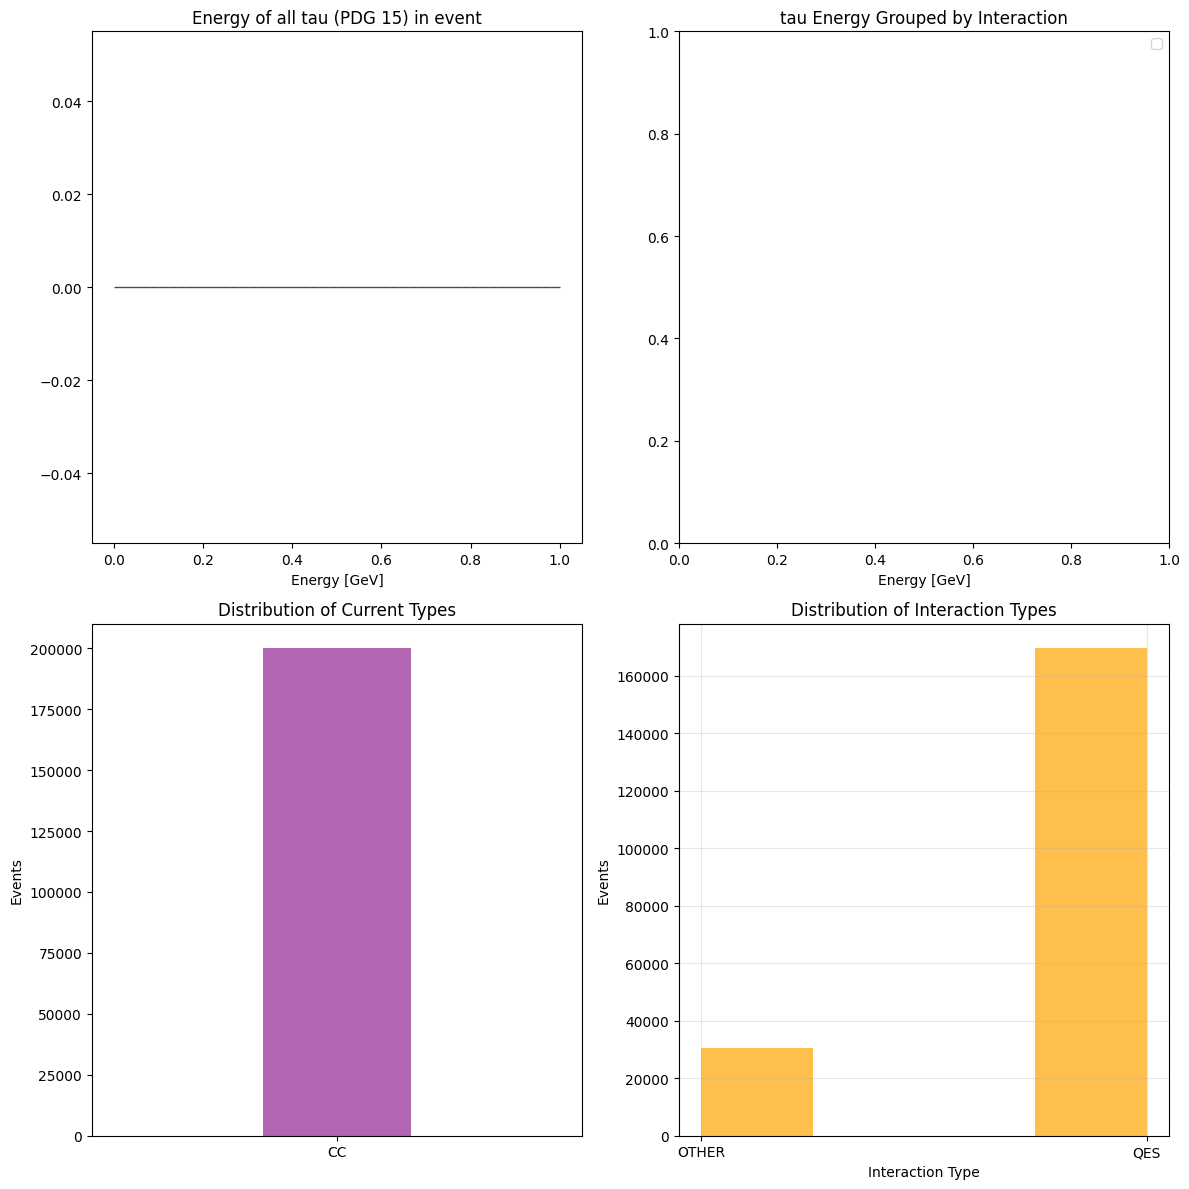

In [ ]:
# plot_CC_energy(df_cc)